In [2]:
# Importation des librairies de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import argparse

# Données
import wrds

#2.1
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from sklearn.metrics import mean_squared_error

#2.2
from statsmodels.tsa.ar_model import AutoReg
import scipy.stats as stats

#2.3 
import statsmodels.api as sm

# 2.4
from dataclasses import dataclass

In [3]:
db = wrds.Connection(wrds_username='lilas_bertot')

Loading library list...
Done
Done


In [4]:
import warnings
warnings.filterwarnings('ignore')

# PRÉPARATION DES DONNÉES

In [5]:
spx_query = """
SELECT date, spindx as prc
FROM crsp.dsi
WHERE date >= '2010-01-01'
AND spindx IS NOT NULL
ORDER BY date;
"""
spx_data = db.raw_sql(spx_query, date_cols=['date'])
spx_data = spx_data.rename(columns={'prc': 'SP500'})
spx_data['date'] = pd.to_datetime(spx_data['date'])

print(spx_data)
print("Nombre d’observations :", len(spx_data))

           date    SP500
0    2010-01-04  1132.99
1    2010-01-05  1136.52
2    2010-01-06  1137.14
3    2010-01-07  1141.69
4    2010-01-08  1144.98
...         ...      ...
3769 2024-12-24  6040.04
3770 2024-12-26  6037.59
3771 2024-12-27  5970.84
3772 2024-12-30  5906.94
3773 2024-12-31  5881.63

[3774 rows x 2 columns]
Nombre d’observations : 3774


In [6]:
# téléchargement indices boursier 3 marchés développés: DAX (Allemagne), Nikkei225 (Japon), FTSE100 (Royaume-Uni)
# téléchargement indices boursier 2 marchés émergents: Bovespa (Brésil), Nifty50 (Inde)

intern_indices_query = """
SELECT 
    datadate,
    MAX(CASE WHEN gvkeyx = '150095' THEN prccd END) AS DAX,
    MAX(CASE WHEN gvkeyx = '150008' THEN prccd END) AS FTSE100,
    MAX(CASE WHEN gvkeyx = '150069' THEN prccd END) AS Nikkei225,
    MAX(CASE WHEN gvkeyx = '150086' THEN prccd END) AS Bovespa,
    MAX(CASE WHEN gvkeyx = '151120' THEN prccd END) AS Nifty50
FROM comp.g_idx_daily
WHERE gvkeyx IN ('150095', '150008', '150069', '150086', '151120')
  AND datadate >= '2010-01-01'
  AND prccd IS NOT NULL
GROUP BY datadate
ORDER BY datadate
"""
intern_indices_data = db.raw_sql(intern_indices_query, date_cols=['datadate'])
intern_indices_data['datadate'] = pd.to_datetime(intern_indices_data['datadate'])

intern_indices_data.columns = ['datadate', 'DAX', 'FTSE100', 'Nikkei225', 'Bovespa', 'Nifty50']

print(intern_indices_data)
print("Nombre d’observations :", len(intern_indices_data))

       datadate       DAX    FTSE100  Nikkei225    Bovespa  Nifty50
0    2010-01-01   5957.43    5412.88   10546.44   68588.41  5201.05
1    2010-01-04    6048.3    5500.34   10654.79   70045.08   5232.2
2    2010-01-05   6031.86     5522.5   10681.83   70239.82   5277.9
3    2010-01-06   6034.33    5530.04   10731.45   70729.34   5281.8
4    2010-01-07   6019.36    5526.72   10681.66   70451.12   5263.1
...         ...       ...        ...        ...        ...      ...
4145 2025-11-05  24049.74   9777.085   50212.27  153294.44  25597.7
4146 2025-11-06  23734.02  9735.7842   50883.68  153338.63  25509.7
4147 2025-11-07  23569.96  9682.5741   50276.37  154063.53  25492.3
4148 2025-11-10  23959.99  9787.1465   50911.76  155257.31  25574.3
4149 2025-11-11  24088.06  9899.5997   50842.93   157748.6  25695.0

[4150 rows x 6 columns]
Nombre d’observations : 4150


In [7]:
data_dict = {
    'DAX': intern_indices_data[['DAX']],
    'FTSE100': intern_indices_data[['FTSE100']],
    'NIKKEI225': intern_indices_data[['Nikkei225']],
    'BOVESPA': intern_indices_data[['Bovespa']],
    'NIFTY50': intern_indices_data[['Nifty50']]
}

# SP500 comme base
spx_df = spx_data.set_index('date')[['SP500']]

# Fusionner sur toutes les dates communes (car différents fériés, etc.)
all_data = spx_df.copy()
for name, df in data_dict.items():
    df = df.set_index(intern_indices_data['datadate']) 
    all_data = all_data.join(df, how='inner')

common_dates = all_data.dropna().index
all_data = all_data.loc[common_dates]

print("Données fusionnées :")
print(all_data)

print("Nombre d’observations par indice après la fusion des données :")
print(all_data.count())

print("Période couverte par tous les indices :")
print(all_data.index.min().date(), "à", all_data.index.max().date())

Données fusionnées :
              SP500       DAX    FTSE100  Nikkei225    Bovespa  Nifty50
2010-01-04  1132.99    6048.3    5500.34   10654.79   70045.08   5232.2
2010-01-05  1136.52   6031.86     5522.5   10681.83   70239.82   5277.9
2010-01-06  1137.14   6034.33    5530.04   10731.45   70729.34   5281.8
2010-01-07  1141.69   6019.36    5526.72   10681.66   70451.12   5263.1
2010-01-08  1144.98   6037.61    5534.24   10798.32    70262.7  5244.75
...             ...       ...        ...        ...        ...      ...
2024-12-24  6040.04  19848.77  8136.9933   39036.85  120766.57  23727.7
2024-12-26  6037.59  19848.77  8136.9933   39568.06   121077.5  23750.2
2024-12-27  5970.84  19984.32  8149.7804   40281.16  120269.31  23813.4
2024-12-30  5906.94  19909.14  8121.0077   39894.54   120283.4  23644.9
2024-12-31  5881.63  19909.14  8173.0239   39894.54   120283.4  23644.8

[3773 rows x 6 columns]
Nombre d’observations par indice après la fusion des données :
SP500        3773
DAX      

# PARTIE 2.1

##### Étapes à suivre 
- Calcul des rendements (faire graphique pour visualiser la volatilité et "deviner" visuellement le degré de corrélation);
- Calcul des corrélations mobiles entre SP500 et autres indices internationaux (faire graphique pour interprétation visuelle);
- Établir les statistiques descriptives de chaque série de corrélation pour interprétation;
- Autocorrélation à lag 1 pour voir la persistance temporelle;
- Détecter la stationnarité de chaque série;
- Interprétation

In [8]:
# Calcul rendements journaliers 
returns = np.log(all_data / all_data.shift(1))
returns = returns.dropna(how="any")

print("Aperçu rendements :")
print(returns)

Aperçu rendements :
               SP500       DAX   FTSE100  Nikkei225   Bovespa   Nifty50
2010-01-05  0.003111 -0.002722  0.004021   0.002535  0.002776  0.008696
2010-01-06  0.000545  0.000409  0.001364   0.004635  0.006945  0.000739
2010-01-07  0.003993 -0.002484 -0.000601   -0.00465 -0.003941 -0.003547
2010-01-08  0.002878  0.003027   0.00136   0.010862 -0.002678 -0.003493
2010-01-11  0.001745  0.000479  0.000692        0.0  0.002428  0.000886
...              ...       ...       ...        ...       ...       ...
2024-12-24  0.010982       0.0  0.004221  -0.003184       0.0 -0.001085
2024-12-26 -0.000406       0.0       0.0   0.013516  0.002571  0.000948
2024-12-27 -0.011117  0.006806   0.00157   0.017862 -0.006697  0.002657
2024-12-30  -0.01076 -0.003769 -0.003537  -0.009644  0.000117 -0.007101
2024-12-31 -0.004294       0.0  0.006385        0.0       0.0 -0.000004

[3772 rows x 6 columns]


<Figure size 1200x600 with 0 Axes>

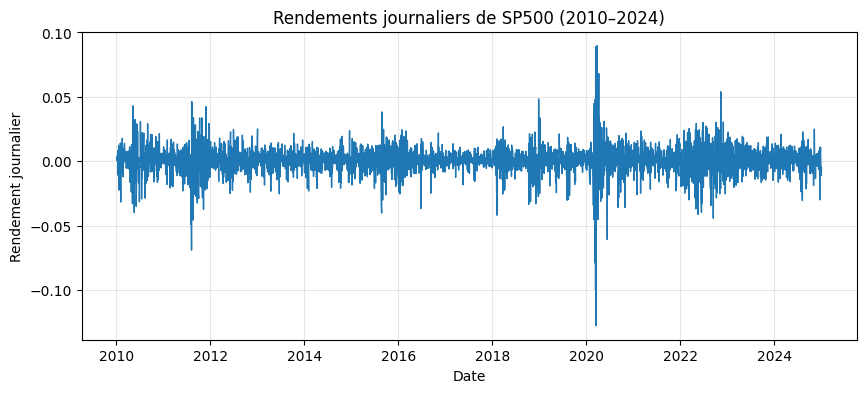

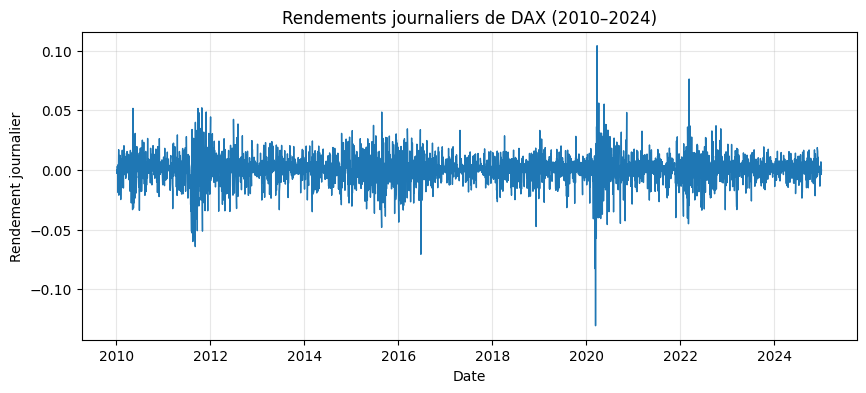

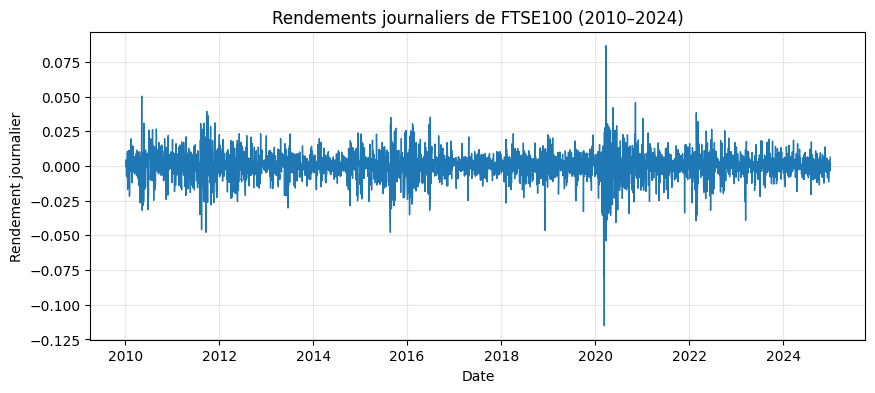

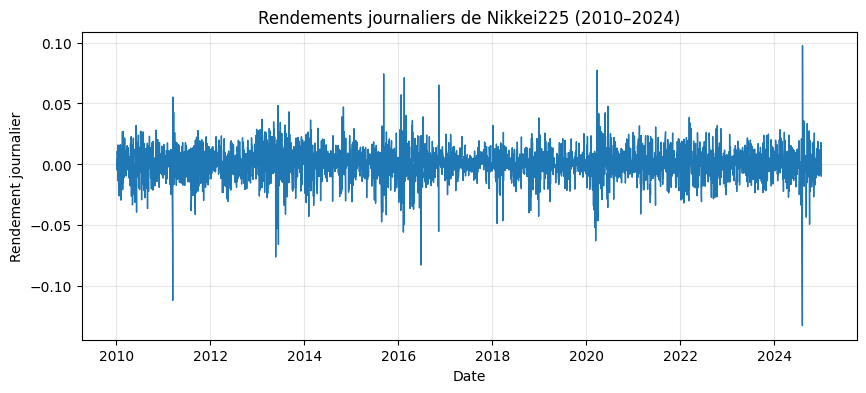

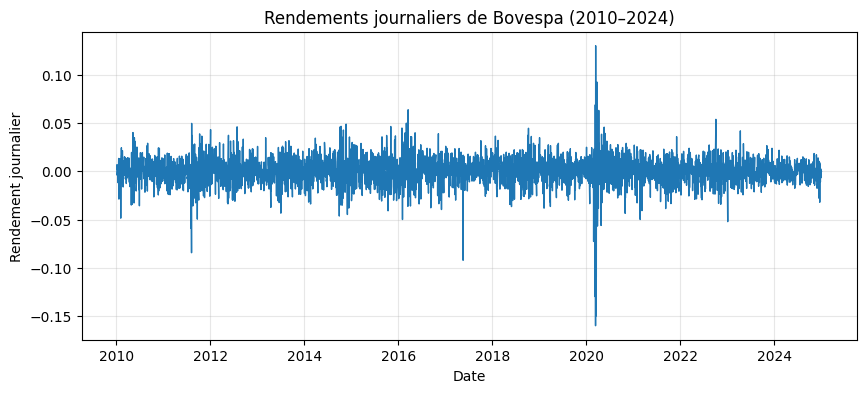

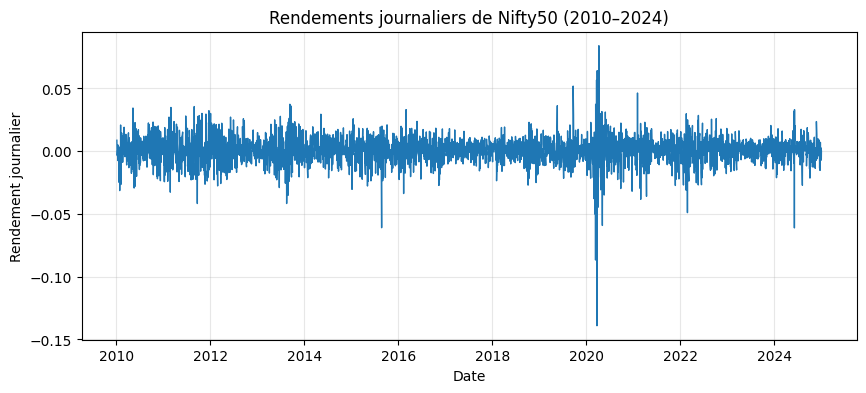

In [9]:
# Graphique des rendements journaliers
plt.figure(figsize=(12,6))
for col in returns.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(returns.index, returns[col], color='tab:blue', linewidth=1)
    plt.title(f"Rendements journaliers de {col} (2010–2024)")
    plt.xlabel("Date")
    plt.ylabel("Rendement journalier")
    plt.grid(True, alpha=0.3)
    plt.show()

In [10]:
# fenêtre 126 jours comme demandé
WIN = 126 

# Corrélation mobile entre SP500 et chaque autre indice
corr_cols = ['DAX','Nikkei225','FTSE100','Bovespa','Nifty50']
corr_mob = pd.DataFrame(index=returns.index)

for col in corr_cols:
    corr_mob[f'corr_SP500_{col}'] = returns['SP500'].rolling(WIN).corr(returns[col])

corr_mob = corr_mob.dropna()

print("Corrélations mobiles (126j) :")
print(corr_mob)
print("\nNombre d'observations par série de corrélation :")
print(corr_mob.count())

Corrélations mobiles (126j) :
            corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
2010-07-06        0.635893              0.210762            0.652437   
2010-07-07        0.633235              0.197942            0.651739   
2010-07-08        0.634284              0.206302            0.653415   
2010-07-09        0.635668              0.208772            0.654471   
2010-07-12        0.635538              0.207499            0.653911   
...                    ...                   ...                 ...   
2024-12-24        0.447845              0.369157            0.364970   
2024-12-26        0.447994              0.368094            0.366220   
2024-12-27        0.437256              0.357290            0.360101   
2024-12-30        0.439044              0.359404            0.363076   
2024-12-31        0.445482              0.357310            0.362917   

            corr_SP500_Bovespa  corr_SP500_Nifty50  
2010-07-06            0.770152            0.326947  

<Figure size 1200x600 with 0 Axes>

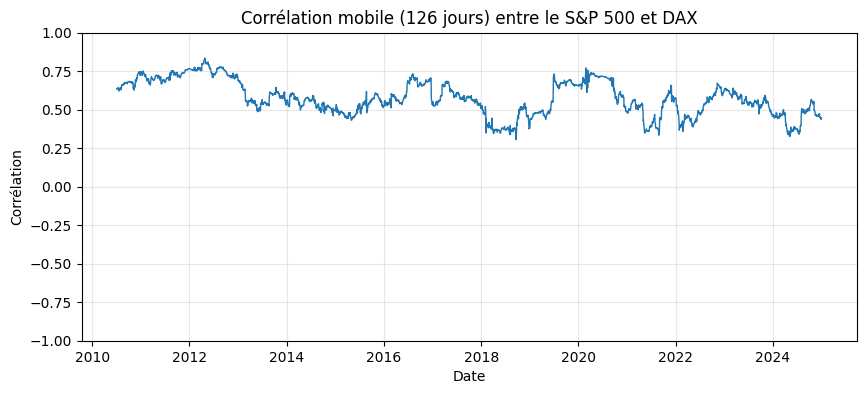

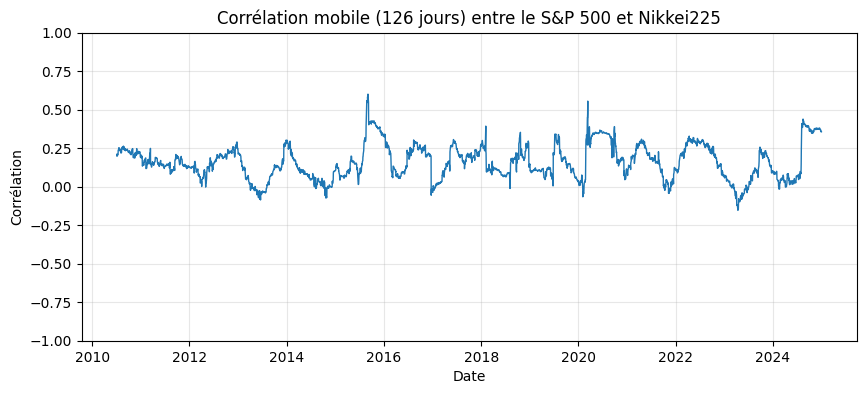

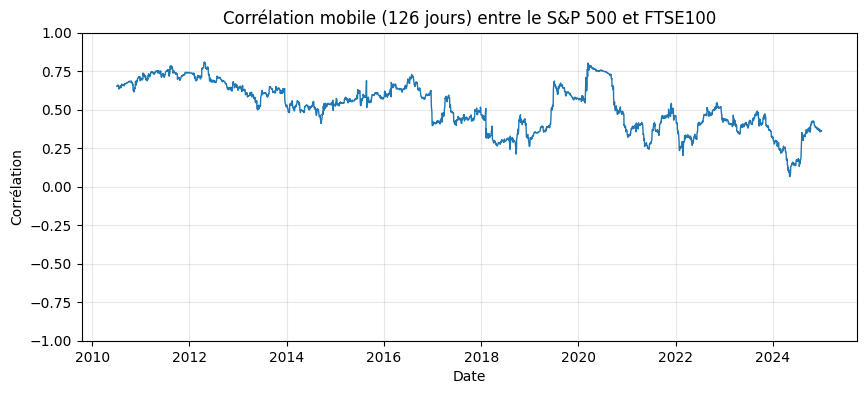

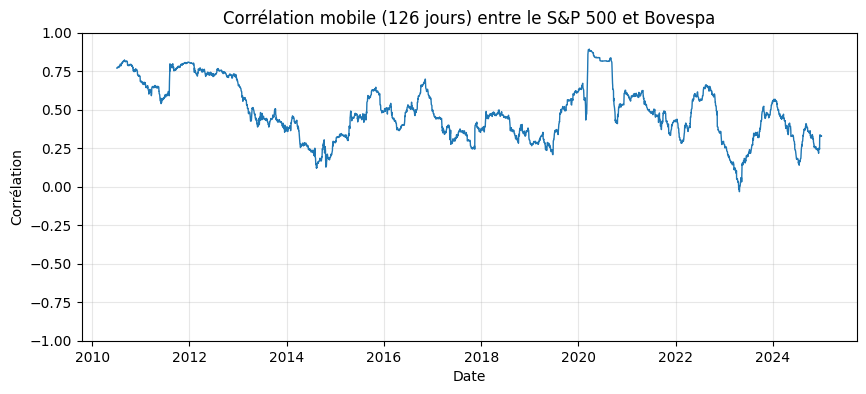

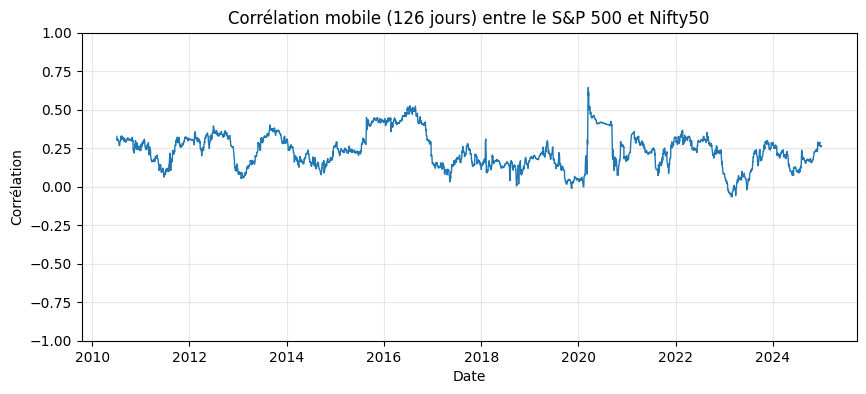

In [11]:
# Graphique des corrélations mobiles
plt.figure(figsize=(12,6))
for col in corr_mob.columns:
    plt.figure(figsize=(10,4))
    plt.plot(corr_mob.index, corr_mob[col], color='tab:blue', linewidth=1)
    plt.title(f"Corrélation mobile (126 jours) entre le S&P 500 et {col.replace('corr_SP500_', '')}")
    plt.xlabel("Date")
    plt.ylabel("Corrélation")
    plt.grid(alpha=0.3)
    plt.ylim(-1, 1)
    plt.show()

In [12]:
# Importation VIX
vix_query = """
SELECT
    date AS datadate,
    vix AS vix_value
FROM cboe.cboe
WHERE date >= '2010-01-01'
  AND date <= '2024-12-31'
  AND vix IS NOT NULL
ORDER BY date
"""

df_vix = db.raw_sql(vix_query)
df_vix['datadate'] = pd.to_datetime(df_vix['datadate'])
df_vix = df_vix.set_index('datadate')
df_vix['log_VIX'] = np.log(df_vix['vix_value'])

print("VIX :")
print(df_vix)

corr_mob_vix = corr_mob.join(df_vix['log_VIX'], how='inner').dropna()

print("\nFusion corrélations et log(VIX) :")
print(corr_mob_vix)

VIX :
            vix_value   log_VIX
datadate                       
2010-01-04      20.04   2.99773
2010-01-05      19.35  2.962692
2010-01-06      19.16  2.952825
2010-01-07      19.06  2.947592
2010-01-08      18.13  2.897568
...               ...       ...
2024-12-24      14.27  2.658159
2024-12-26      14.73  2.689886
2024-12-27      15.95  2.769459
2024-12-30       17.4   2.85647
2024-12-31      17.35  2.853593

[3793 rows x 2 columns]

Fusion corrélations et log(VIX) :
            corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
2010-07-06        0.635893              0.210762            0.652437   
2010-07-07        0.633235              0.197942            0.651739   
2010-07-08        0.634284              0.206302            0.653415   
2010-07-09        0.635668              0.208772            0.654471   
2010-07-12        0.635538              0.207499            0.653911   
...                    ...                   ...                 ...   
2024-12-24    

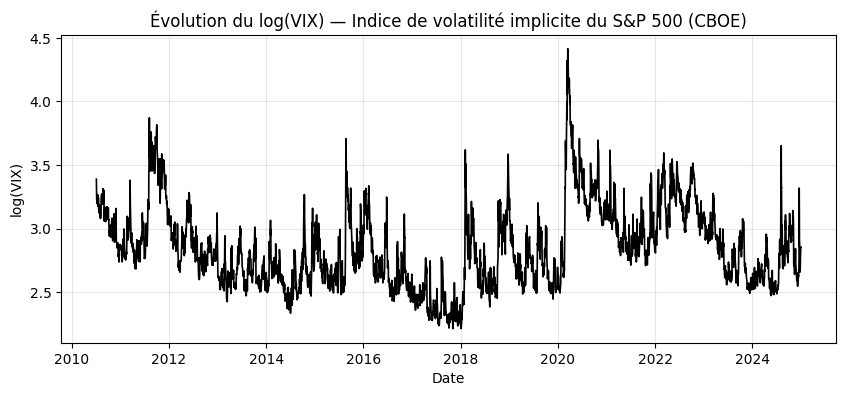

In [13]:
# Graphique log(VIX)
plt.figure(figsize=(10,4))
plt.plot(corr_mob_vix.index, corr_mob_vix['log_VIX'], color='black', linewidth=1.2)
plt.title("Évolution du log(VIX) — Indice de volatilité implicite du S&P 500 (CBOE)")
plt.xlabel("Date")
plt.ylabel("log(VIX)")
plt.grid(alpha=0.3)
plt.show()

In [14]:
# Calcul statistiques descriptives
def acf1(x):
    x = x.dropna()
    return x.autocorr(lag=1)

desc = corr_mob_vix.agg(['mean','std','min','max'])
q = corr_mob_vix.quantile([0.05,0.50,0.95])
acf1_vals = corr_mob_vix.apply(acf1)

print("Statistiques descriptives (moy, écart-type, min, max) pour chaque corrélation:")
print(desc.round(3))

print("\nQuantiles (5%, 50%, 95%) :")
print(q.round(3))

print("\nAutocorrélation au lag 1 :")
print(acf1_vals.round(3))

Statistiques descriptives (moy, écart-type, min, max) pour chaque corrélation:
      corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
mean           0.574                 0.160               0.517   
std            0.111                 0.112               0.153   
min            0.305                -0.153               0.065   
max            0.835                 0.601               0.810   

      corr_SP500_Bovespa  corr_SP500_Nifty50  log_VIX  
mean               0.483               0.231    2.846  
std                0.182               0.114    0.319  
min               -0.032              -0.065    2.213  
max                0.893               0.645    4.415  

Quantiles (5%, 50%, 95%) :
      corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
0.05           0.375                -0.012               0.274   
0.50           0.565                 0.150               0.525   
0.95           0.751                 0.361               0.747   

      corr_SP500_

In [15]:
# Nettoyage : Assurer le même nombre d'observations pour chaque série
corr_mob_clean = corr_mob.dropna(how='any')
print(f"Nettoyage des données : {len(corr_mob_clean)} observations pour toutes les séries")

Nettoyage des données : 3647 observations pour toutes les séries


In [16]:
# Test de Dickey-Fuller Augmenté (ADF)
def adf_summary(series):
    s = series.dropna()
    res = adfuller(s, regression='c', autolag='AIC')  
    out = {
        'ADF_stat': res[0],
        'p_value':  res[1],
        'lags':     res[2],
        'n_obs':    len(s),
        'Conclusion': 'Stationnaire' if res[1] < 0.05 else 'Non-stationnaire'
    }
    return pd.Series(out)

adf_table = corr_mob_clean.apply(adf_summary).T
print("RÉSULTATS TEST ADF (Dickey-Fuller Augmenté)")
print(adf_table.round(4))

RÉSULTATS TEST ADF (Dickey-Fuller Augmenté)
                      ADF_stat   p_value lags n_obs        Conclusion
corr_SP500_DAX       -3.087255  0.027511   17  3647      Stationnaire
corr_SP500_Nikkei225 -4.366951  0.000339   13  3647      Stationnaire
corr_SP500_FTSE100   -2.378747  0.147825    3  3647  Non-stationnaire
corr_SP500_Bovespa   -3.048849  0.030578    6  3647      Stationnaire
corr_SP500_Nifty50   -3.854658  0.002395    8  3647      Stationnaire


In [17]:
# Test KPSS complémentaire
def kpss_summary(series):
    s = series.dropna()
    res = kpss(s, regression='c', nlags='auto')
    out = {
        'KPSS_stat': res[0],
        'p_value': res[1],
        'lags': res[2],
        'n_obs': len(s),
        'Conclusion': 'Stationnaire' if res[1] > 0.05 else 'Non-stationnaire'
    }
    return pd.Series(out)

kpss_table = corr_mob_clean.apply(kpss_summary).T
print("RÉSULTATS TEST KPSS (COMPLÉMENT)")
print(kpss_table.round(4))


RÉSULTATS TEST KPSS (COMPLÉMENT)
                     KPSS_stat   p_value lags n_obs        Conclusion
corr_SP500_DAX        2.533298      0.01   38  3647  Non-stationnaire
corr_SP500_Nikkei225  0.181811       0.1   38  3647      Stationnaire
corr_SP500_FTSE100    4.736911      0.01   38  3647  Non-stationnaire
corr_SP500_Bovespa    1.724129      0.01   38  3647  Non-stationnaire
corr_SP500_Nifty50    0.686996  0.014728   38  3647  Non-stationnaire


In [18]:
# Tableau comparatif ADF vs KPSS
comparison_table = pd.DataFrame(index=adf_table.index)

# ADF
comparison_table['ADF_stat'] = adf_table['ADF_stat']
comparison_table['ADF_p_value'] = adf_table['p_value']
comparison_table['ADF_Conclusion'] = adf_table['Conclusion']

# KPSS
comparison_table['KPSS_stat'] = kpss_table['KPSS_stat']
comparison_table['KPSS_p_value'] = kpss_table['p_value']
comparison_table['KPSS_Conclusion'] = kpss_table['Conclusion']

# Décision finale
def final_stationarity_decision(row):
    """
    Règles de décision:
    - Stationnaire: ADF rejette H0 (p < 0.05) ET KPSS accepte H0 (p > 0.05)
    - Non-stationnaire: ADF accepte H0 (p >= 0.05) ET KPSS rejette H0 (p <= 0.05)
    - Ambigu: résultats contradictoires
    """
    adf_reject = row['ADF_p_value'] < 0.05  
    kpss_accept = row['KPSS_p_value'] > 0.05 
    
    if adf_reject and kpss_accept:
        return 'Stationnaire'
    elif (not adf_reject) and (not kpss_accept):
        return 'Non-stationnaire'
    else:
        return 'Ambigu'

comparison_table['Décision Finale'] = comparison_table.apply(final_stationarity_decision, axis=1)

print("RÉSUMÉ : TESTS DE STATIONNARITÉ (ADF vs KPSS)")
print(comparison_table.round(4).to_string())



RÉSUMÉ : TESTS DE STATIONNARITÉ (ADF vs KPSS)
                      ADF_stat ADF_p_value    ADF_Conclusion KPSS_stat KPSS_p_value   KPSS_Conclusion   Décision Finale
corr_SP500_DAX       -3.087255    0.027511      Stationnaire  2.533298         0.01  Non-stationnaire            Ambigu
corr_SP500_Nikkei225 -4.366951    0.000339      Stationnaire  0.181811          0.1      Stationnaire      Stationnaire
corr_SP500_FTSE100   -2.378747    0.147825  Non-stationnaire  4.736911         0.01  Non-stationnaire  Non-stationnaire
corr_SP500_Bovespa   -3.048849    0.030578      Stationnaire  1.724129         0.01  Non-stationnaire            Ambigu
corr_SP500_Nifty50   -3.854658    0.002395      Stationnaire  0.686996     0.014728  Non-stationnaire            Ambigu


# PARTIE 2.2

##### Approche méthodologique
**Objectif** : Évaluer la performance et la fragilité de modèles AR(p) pour prévoir les corrélations one-step-ahead.

**Stratégie d'estimation** :
- **Séries stationnaires** : modélisation en **niveaux**
- **Séries non-stationnaires** : modélisation en **différences premières**
- **Séries ambiguës** : tester **les deux approches** et choisir le meilleur RMSE

**Split des données** :
- **80% training** : estimation du modèle
- **20% test** : évaluation hors-échantillon (période incluant COVID-19 pour tester la robustesse)

**Sélection de l'ordre p** : Critère d'information de Hannan-Quinn (HQIC)

**Métriques d'évaluation** :
- **RMSE** (Root Mean Squared Error) : précision des prévisions
- **Coverage** : % de réalisations capturées par les intervalles de confiance à 95%

In [54]:
# Split train+test : 80% train, 20% test 
# Test: centré sur COVID, train: avant + après période COVID - permet de voir effet plus claire période de crise

n_total = len(corr_mob_clean)
covid_start = pd.Timestamp('2020-01-01')

# Taille du test set (20% du total)
test_size = int(n_total * 0.20)

# Trouver l'index de COVID
covid_idx = corr_mob_clean.index.searchsorted(covid_start)

# Centrer test set autour de COVID
# Prendre test_size/2 avant et après COVID
test_start_idx = covid_idx - test_size // 2
test_end_idx = test_start_idx + test_size

# Ajuster si dépasse  bornes
if test_start_idx < 0:
    test_start_idx = 0
    test_end_idx = test_size
elif test_end_idx > n_total:
    test_end_idx = n_total
    test_start_idx = n_total - test_size

# Créer train + test
train_before = corr_mob_clean.iloc[:test_start_idx]
test_data = corr_mob_clean.iloc[test_start_idx:test_end_idx]
train_after = corr_mob_clean.iloc[test_end_idx:]

train_data = pd.concat([train_before, train_after])

print("SPLIT DES DONNÉES : TEST CENTRAL (inclue période COVID)")
print(f"\nTraining set : {len(train_data)} observations ({len(train_data)/n_total*100:.1f}%)")
print(f"    Partie 1 (avant test) : {len(train_before)} observations allant de {train_before.index[0].date()} à {train_before.index[-1].date()}")
print(f"    Partie 2 (après test) : {len(train_after)} observations allant de {train_after.index[0].date()} à {train_after.index[-1].date()}")
print(f"\nTest set : {len(test_data)} observations ({len(test_data)/n_total*100:.1f}%)")
print(f"    Période : de {test_data.index[0].date()} à {test_data.index[-1].date()}")
print(f"\nTotal observations : {n_total}")

# Vérification période COVID inclus test
if test_data.index[0] <= covid_start <= test_data.index[-1]:
    print(f"\nPériode COVID (janvier 2020) comprise dans test set")
else:
    print(f"\nPériode COVID pas dans le test set")

SPLIT DES DONNÉES : TEST CENTRAL (inclue période COVID)

Training set : 2918 observations (80.0%)
    Partie 1 (avant test) : 2026 observations allant de 2010-07-06 à 2018-07-20
    Partie 2 (après test) : 892 observations allant de 2021-06-16 à 2024-12-31

Test set : 729 observations (20.0%)
    Période : de 2018-07-23 à 2021-06-15

Total observations : 3647

Période COVID (janvier 2020) comprise dans test set


In [55]:
# HQIC pour trouver p optimal AR(p)
def select_ar_order(series, max_p=10):
    hqic_values = {}
    
    for p in range(1, max_p + 1):
        try:
            model = AutoReg(series, lags=p, old_names=False)
            results = model.fit()
            hqic_values[p] = results.hqic
        except:
            hqic_values[p] = np.inf
    
    p_optimal = min(hqic_values, key=hqic_values.get)
    
    return p_optimal, hqic_values

print("SÉLECTION DE L'ORDRE OPTIMAL AR(p) AVEC HQIC")

# Tableau recap
results_selection = []

for col in train_data.columns:
    serie_name = col.replace('corr_SP500_', '')
    test_series = train_data[col].dropna()
    p_opt, hqic_dict = select_ar_order(test_series, max_p=10)
    
    row = {
        'Série': serie_name,
        'AR(p) optimal': p_opt,
        'HQIC optimal': hqic_dict[p_opt]
    }
    
    results_selection.append(row)

df_selection = pd.DataFrame(results_selection)

print("\n" + df_selection.to_string(index=False))

SÉLECTION DE L'ORDRE OPTIMAL AR(p) AVEC HQIC

    Série  AR(p) optimal  HQIC optimal
      DAX              1 -18415.795093
Nikkei225              1 -16155.397658
  FTSE100              1 -17925.046689
  Bovespa              4 -17940.916228
  Nifty50              1 -17005.799347


In [56]:
# Estimation modèle AR + calcul RMSE 
def estimate_ar_model(train_series, test_series, p, in_differences=False):
    # Transformer en différences si nécessaire
    if in_differences:
        train_transformed = train_series.diff().dropna()
        test_transformed = test_series.diff().dropna()
    else:
        train_transformed = train_series
        test_transformed = test_series
    
    # Estimation du modèle AR(p)
    model = AutoReg(train_transformed, lags=p, old_names=False)
    results = model.fit()
    
    # Prévisions one-step-ahead sur le test set
    forecasts = []
    lower_bounds = []
    upper_bounds = []
    
    for i in range(len(test_transformed)):
        if i == 0:
            history = train_transformed.copy()
        else:
            history = pd.concat([train_transformed, test_transformed.iloc[:i]])
        
        # Réestimer le modèle sur l'historique complet (rolling)
        model_rolling = AutoReg(history, lags=p, old_names=False)
        results_rolling = model_rolling.fit()
        
        # Prévision one-step-ahead
        forecast = results_rolling.forecast(steps=1)
        forecasts.append(forecast.values[0])
        
        # Intervalle de confiance à 95%
        pred_summary = results_rolling.get_prediction(start=len(history), end=len(history))
        pred_df = pred_summary.summary_frame(alpha=0.05)
        lower_bounds.append(pred_df['mean_ci_lower'].values[0])
        upper_bounds.append(pred_df['mean_ci_upper'].values[0])
    
    forecasts = np.array(forecasts)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    
    # Si en différences, reconvertir en niveaux pour le calcul du RMSE
    if in_differences:
        forecasts_level = []
        lower_level = []
        upper_level = []
        for i in range(len(test_transformed)):
            if i == 0:
                base = train_series.iloc[-1]
            else:
                # Utiliser test_series avec l'index ajusté
                base = test_series.iloc[i]
            forecasts_level.append(base + forecasts[i])
            lower_level.append(base + lower_bounds[i])
            upper_level.append(base + upper_bounds[i])
        
        forecasts_level = np.array(forecasts_level)
        lower_level = np.array(lower_level)
        upper_level = np.array(upper_level)
        actuals = test_series.iloc[1:len(test_transformed)+1].values
    else:
        forecasts_level = forecasts
        lower_level = lower_bounds
        upper_level = upper_bounds
        actuals = test_series.values
    
    # Calcul RMSE
    rmse = np.sqrt(mean_squared_error(actuals, forecasts_level))
    
    # Calcul couverture (% de valeurs dans IC 95%)
    within_ci = np.sum((actuals >= lower_level) & (actuals <= upper_level))
    coverage = within_ci / len(actuals) * 100
    
    # Coefficients et Std errors
    coefficients = results.params
    std_errors = results.bse
    
    result_dict = {
        'p': p,
        'coefficients': coefficients,
        'std_errors': std_errors,
        'rmse': rmse,
        'coverage': coverage,
        'forecasts': forecasts_level,
        'lower_ci': lower_level,
        'upper_ci': upper_level,
        'actuals': actuals,
        'in_differences': in_differences
    }
    
    # Si en différences, ajouter aussi les prévisions en différences pour les graphiques
    if in_differences:
        result_dict['forecasts_diff'] = forecasts
        result_dict['lower_ci_diff'] = lower_bounds
        result_dict['upper_ci_diff'] = upper_bounds
        result_dict['actuals_diff'] = test_transformed.values
    
    return result_dict

In [57]:
# Déterminer les modèles optimaux pour chaque série
print("SÉLECTION DES MODÈLES OPTIMAUX")

results_dict = {}
comparison_rows = []

for col in corr_mob_clean.columns:
    serie_name = col.replace('corr_SP500_', '')
    
    # Extraire train et test pour série
    train_series = train_data[col].dropna()
    test_series = test_data[col].dropna()
    
    # Récupérer stationnarité
    decision = comparison_table.loc[col, 'Décision Finale']

    row = {
        'Série': serie_name,
        'Stationnarité': decision,
        'RMSE (niveaux)': None,
        'RMSE (différences)': None,
        'Approche optimale': None,
        'p optimal': None,
        'RMSE optimal': None
    }
    
    # Détermination modèle optimal selon stationnarité
    if 'Stationnaire' in decision and 'Ambigu' not in decision:
        # Série stationnaire : modéliser en niveaux uniquement
        p_level, _ = select_ar_order(train_series, max_p=10)
        result_level = estimate_ar_model(train_series, test_series, p_level, in_differences=False)
        
        row['RMSE (niveaux)'] = result_level['rmse']
        row['Approche optimale'] = 'Niveaux'
        row['p optimal'] = p_level
        row['RMSE optimal'] = result_level['rmse']
        
        results_dict[serie_name] = result_level
        
    elif 'Non-stationnaire' in decision and 'Ambigu' not in decision:
        # Série non-stationnaire : modéliser en différences uniquement
        train_diff = train_series.diff().dropna()
        p_diff, _ = select_ar_order(train_diff, max_p=10)
        result_diff = estimate_ar_model(train_series, test_series, p_diff, in_differences=True)
        
        row['RMSE (différences)'] = result_diff['rmse']
        row['Approche optimale'] = 'Différences'
        row['p optimal'] = p_diff
        row['RMSE optimal'] = result_diff['rmse']
        
        results_dict[serie_name] = result_diff
        
    else:
        # Série ambiguë : tester les DEUX approches et choisir le meilleur RMSE
        
        # Approche 1 : Niveaux
        p_level, _ = select_ar_order(train_series, max_p=10)
        result_level = estimate_ar_model(train_series, test_series, p_level, in_differences=False)
        
        # Approche 2 : Différences
        train_diff = train_series.diff().dropna()
        p_diff, _ = select_ar_order(train_diff, max_p=10)
        result_diff = estimate_ar_model(train_series, test_series, p_diff, in_differences=True)
        
        row['RMSE (niveaux)'] = result_level['rmse']
        row['RMSE (différences)'] = result_diff['rmse']
        
        # Choisir le modèle avec le meilleur RMSE
        if result_level['rmse'] < result_diff['rmse']:
            row['Approche optimale'] = 'Niveaux'
            row['p optimal'] = p_level
            row['RMSE optimal'] = result_level['rmse']
            results_dict[serie_name] = result_level
        else:
            row['Approche optimale'] = 'Différences'
            row['p optimal'] = p_diff
            row['RMSE optimal'] = result_diff['rmse']
            results_dict[serie_name] = result_diff
    
    comparison_rows.append(row)

# Créer et afficher le DataFrame de comparaison
df_comparison = pd.DataFrame(comparison_rows)

print("\nTABLEAU COMPARATIF : NIVEAUX vs DIFFÉRENCES")
print(df_comparison.to_string(index=False))


SÉLECTION DES MODÈLES OPTIMAUX

TABLEAU COMPARATIF : NIVEAUX vs DIFFÉRENCES
    Série    Stationnarité  RMSE (niveaux)  RMSE (différences) Approche optimale  p optimal  RMSE optimal
      DAX           Ambigu        0.014301            0.014339           Niveaux          1      0.014301
Nikkei225     Stationnaire        0.027178                 NaN           Niveaux          1      0.027178
  FTSE100 Non-stationnaire             NaN            0.013980       Différences          1      0.013980
  Bovespa           Ambigu        0.013816            0.013908           Niveaux          4      0.013816
  Nifty50           Ambigu        0.020486            0.020572           Niveaux          1      0.020486

TABLEAU COMPARATIF : NIVEAUX vs DIFFÉRENCES
    Série    Stationnarité  RMSE (niveaux)  RMSE (différences) Approche optimale  p optimal  RMSE optimal
      DAX           Ambigu        0.014301            0.014339           Niveaux          1      0.014301
Nikkei225     Stationnaire     

In [58]:
# Estimations AR avec coefficients et standard errors
print("ESTIMATION DES MODÈLES AR")

summary_rows = []

for serie_name, result in results_dict.items():
    p = result['p']
    coeffs = result['coefficients']
    std_errs = result['std_errors']
    rmse = result['rmse']
    coverage = result['coverage']
    approach = "Différences" if result['in_differences'] else "Niveaux"
    
    row = {
        'Série': serie_name,
        'Approche': approach,
        'Ordre p': p,
        'RMSE': rmse,
        'Coverage 95%': coverage
    }
    
    # Ajouter coefficients 
    for i in range(1, p + 1):
        coeff_name = f'y.L{i}'
        if coeff_name in coeffs.index:
            row[f'AR({i})'] = coeffs[coeff_name]
            row[f'SE AR({i})'] = std_errs[coeff_name]
    
    # Ajouter constante
    if 'const' in coeffs.index:
        row['Constante'] = coeffs['const']
        row['SE Const'] = std_errs['const']
    
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

base_cols = ['Série', 'Approche', 'Ordre p', 'RMSE', 'Coverage 95%']
coeff_cols = [col for col in summary_df.columns if col not in base_cols]
summary_df = summary_df[base_cols + coeff_cols]

print(summary_df.to_string(index=False))


ESTIMATION DES MODÈLES AR
    Série    Approche  Ordre p     RMSE  Coverage 95%  Constante  SE Const
      DAX     Niveaux        1 0.014301     92.592593   0.002354  0.001014
Nikkei225     Niveaux        1 0.027178     92.729767   0.001346  0.000470
  FTSE100 Différences        1 0.013980     92.994505  -0.000098  0.000207
  Bovespa     Niveaux        4 0.013816     93.689986   0.001105  0.000580
  Nifty50     Niveaux        1 0.020486     91.632373   0.001716  0.000579


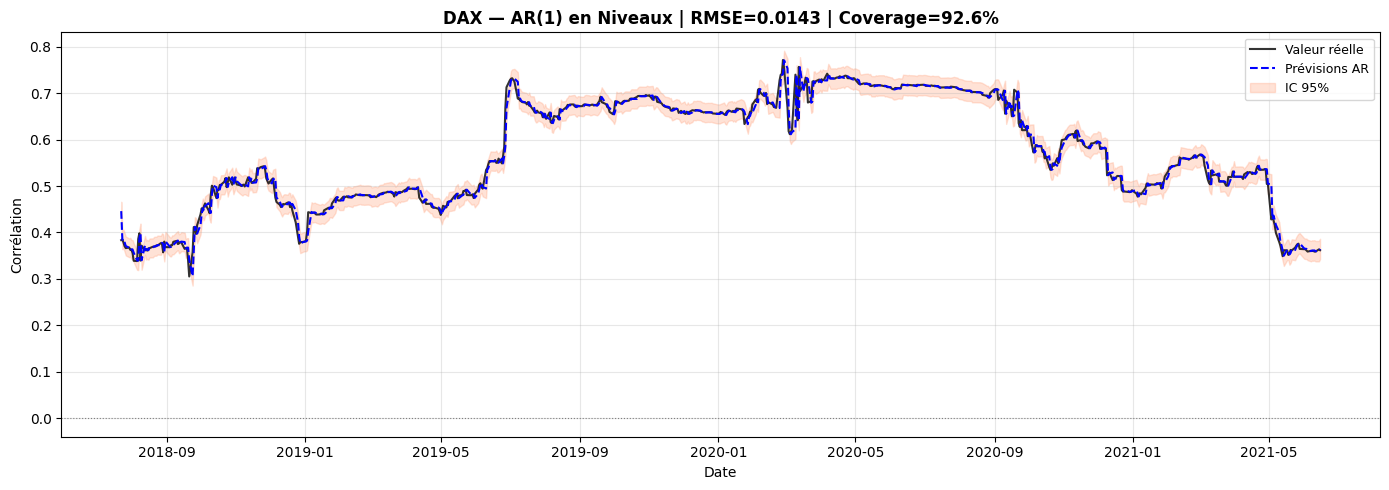

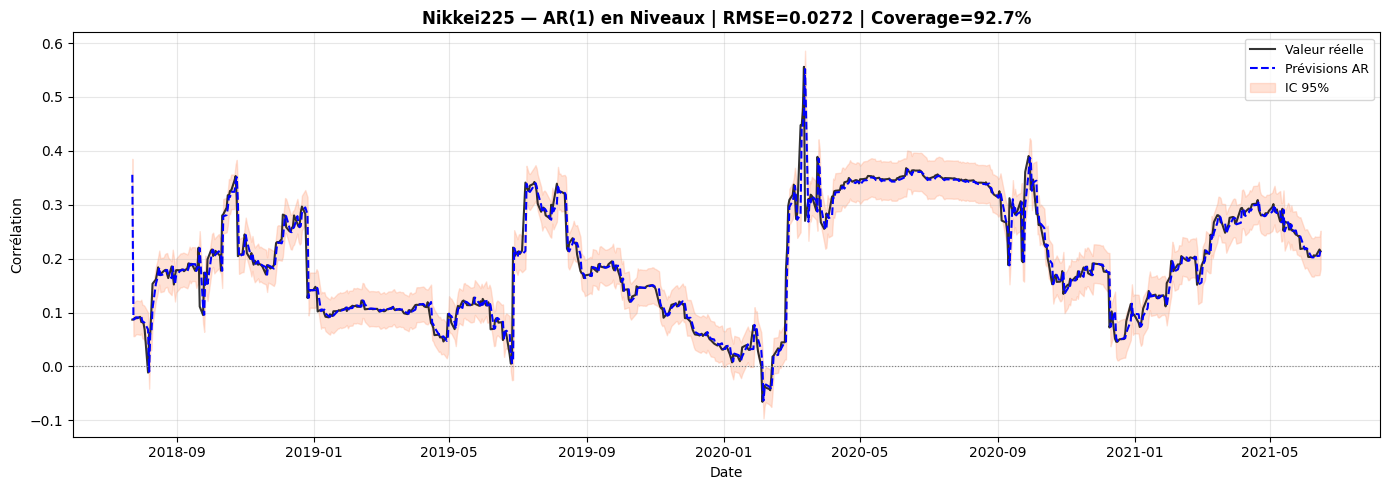

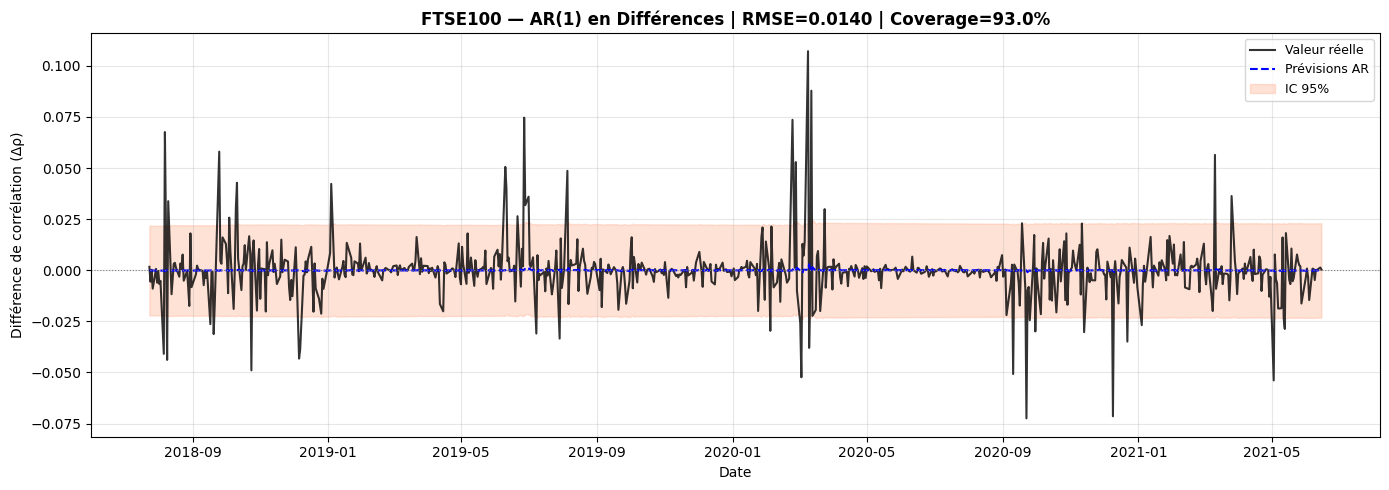

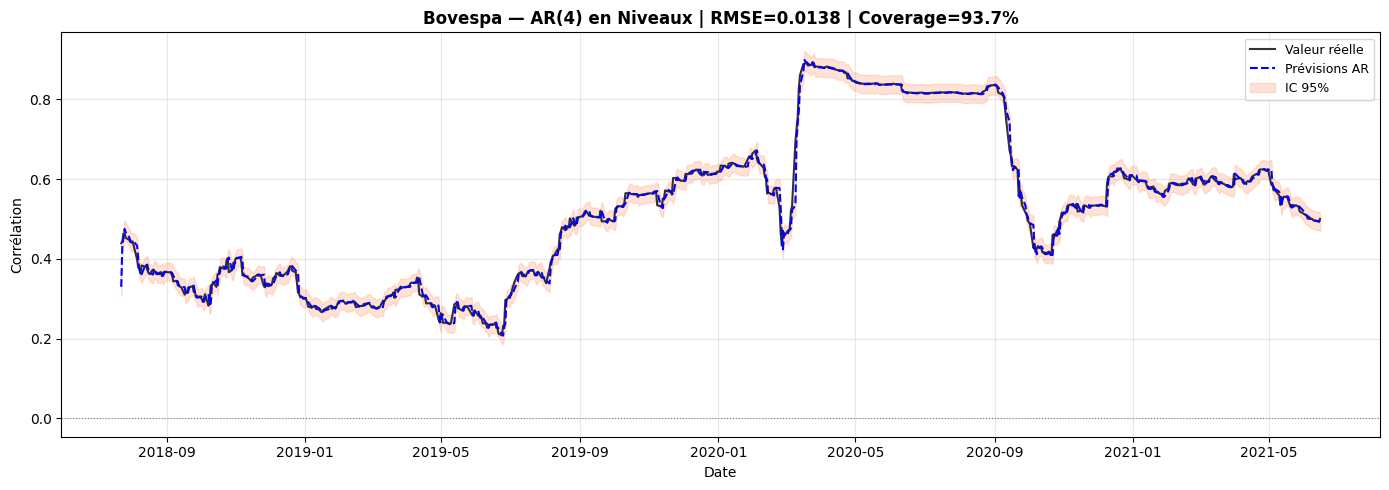

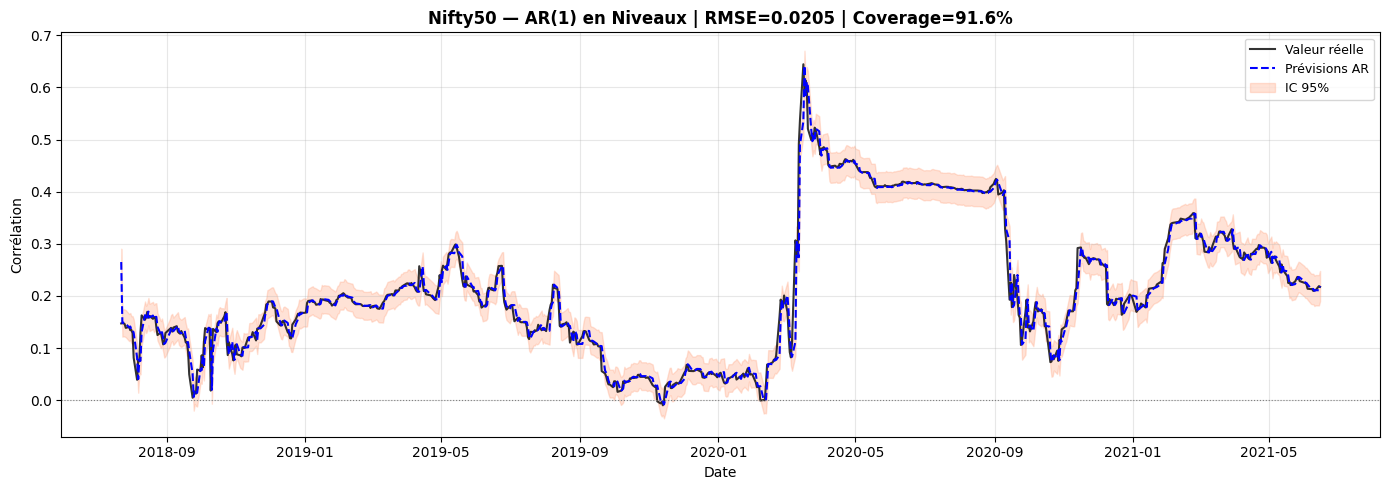

In [59]:
# Graphiques individuels : Prévisions vs Réel avec intervalles de confiance 95%

for serie_name, result in results_dict.items():
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    
    # Récupérer les données
    test_series = test_data[f'corr_SP500_{serie_name}'].dropna()
    in_differences = result['in_differences']
    
    if in_differences:
        # Pour les modèles en différences : afficher les différences premières
        actuals_diff = test_series.diff().dropna().values
        forecasts = result['forecasts_diff']
        lower_ci = result['lower_ci_diff']
        upper_ci = result['upper_ci_diff']
        test_dates = test_series.index[1:len(actuals_diff)+1]
        ylabel = 'Différence de corrélation (Δρ)'
    else:
        # Pour les modèles en niveaux : afficher les niveaux
        forecasts = result['forecasts']
        lower_ci = result['lower_ci']
        upper_ci = result['upper_ci']
        actuals_diff = result['actuals']
        test_dates = test_series.index[:len(actuals_diff)]
        ylabel = 'Corrélation'
    
    # Tracer les valeurs réelles
    ax.plot(test_dates, actuals_diff, label='Valeur réelle', 
            color='black', linewidth=1.5, alpha=0.8)
    
    # Tracer les prévisions
    ax.plot(test_dates, forecasts, label='Prévisions AR', 
            color='blue', linewidth=1.5, linestyle='--')
    
    # Intervalle de confiance à 95%
    ax.fill_between(test_dates, lower_ci, upper_ci, 
                     color='lightsalmon', alpha=0.3, label='IC 95%')
    
    # Annotations
    rmse = result['rmse']
    coverage = result['coverage']
    p = result['p']
    approach = "Différences" if in_differences else "Niveaux"
    
    ax.set_title(f"{serie_name} — AR({p}) en {approach} | RMSE={rmse:.4f} | Coverage={coverage:.1f}%",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()


Période de test disponible : de 2018-07-23 à 2021-06-15



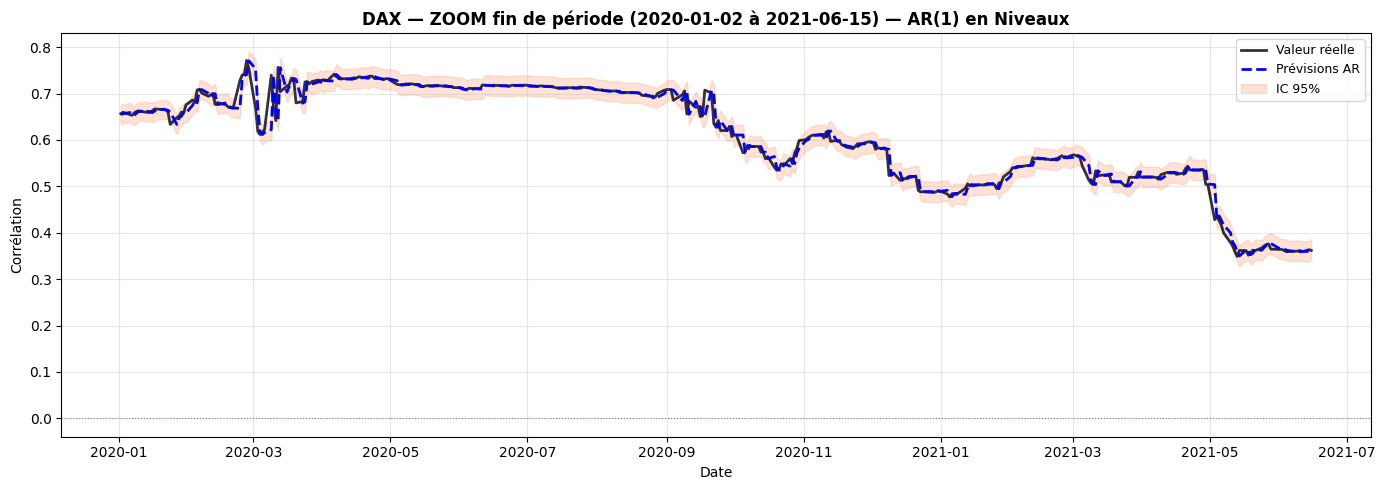

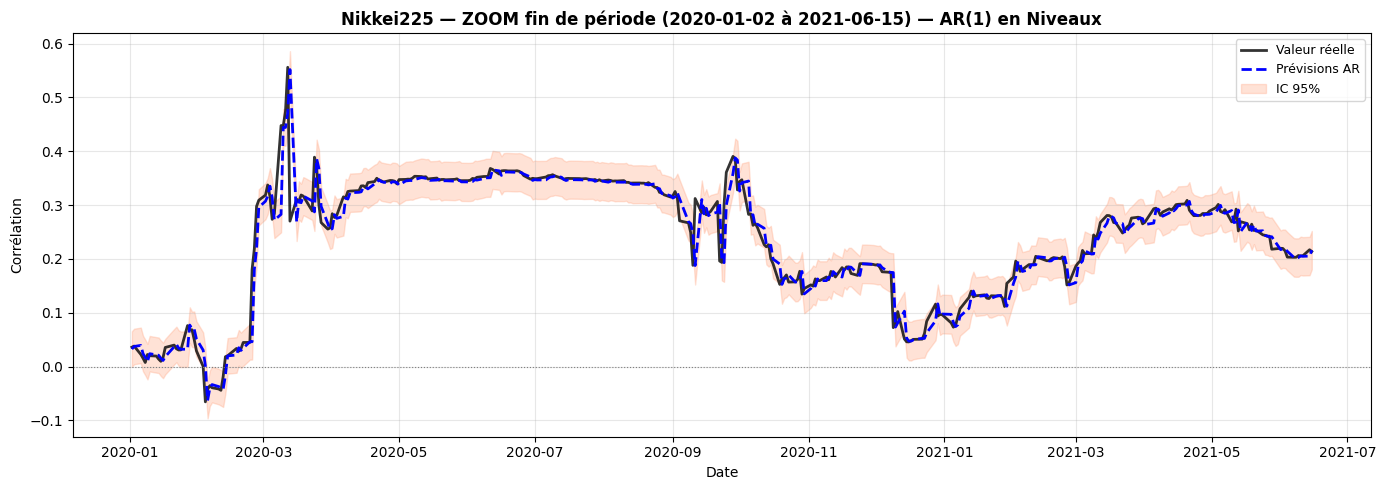

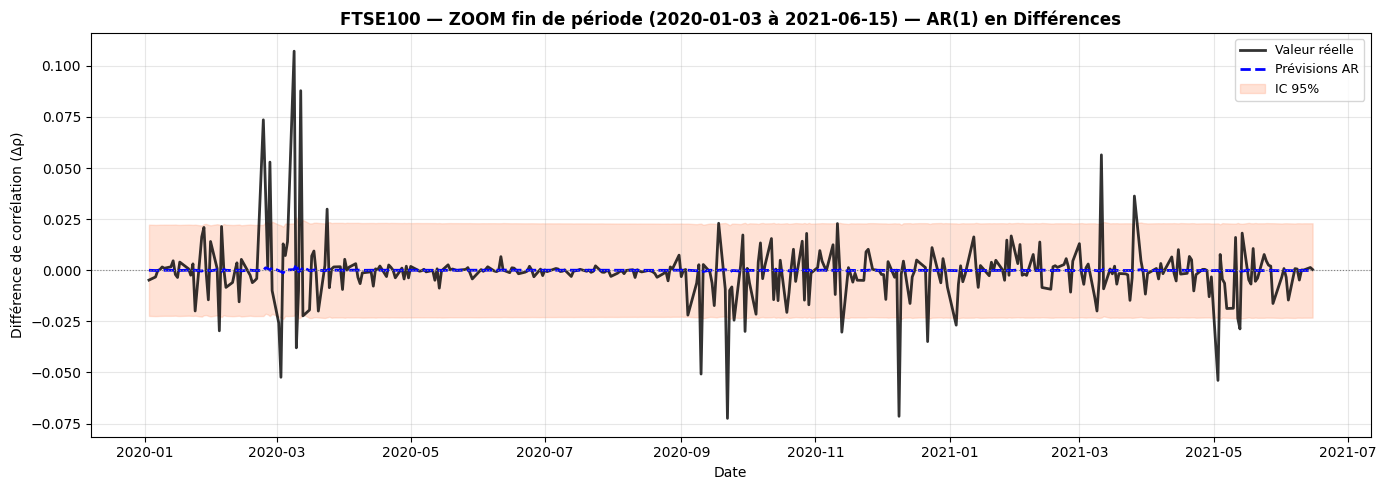

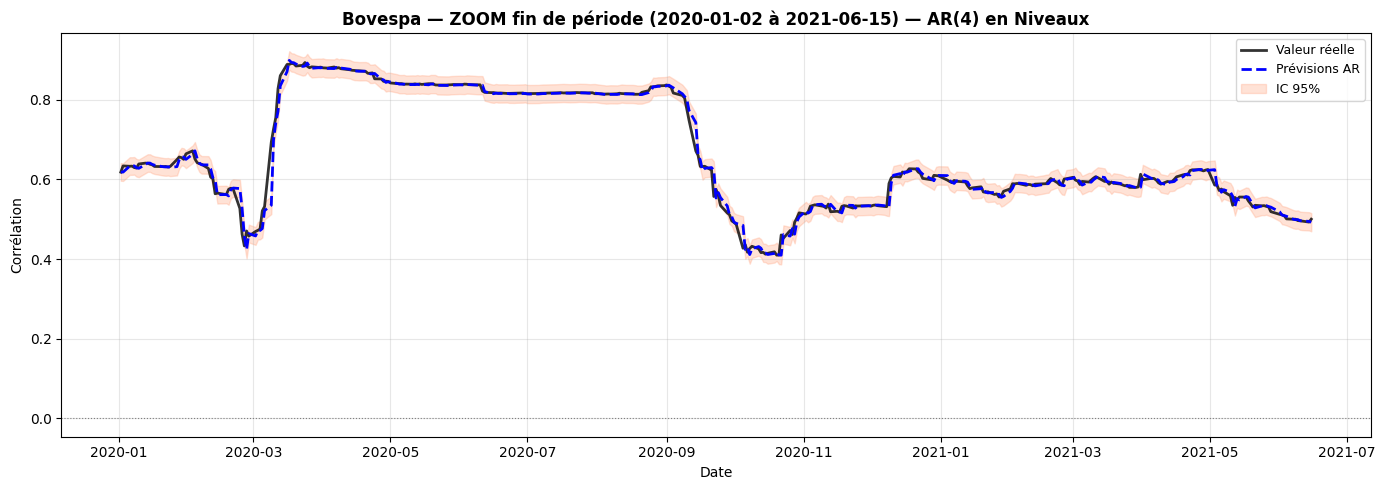

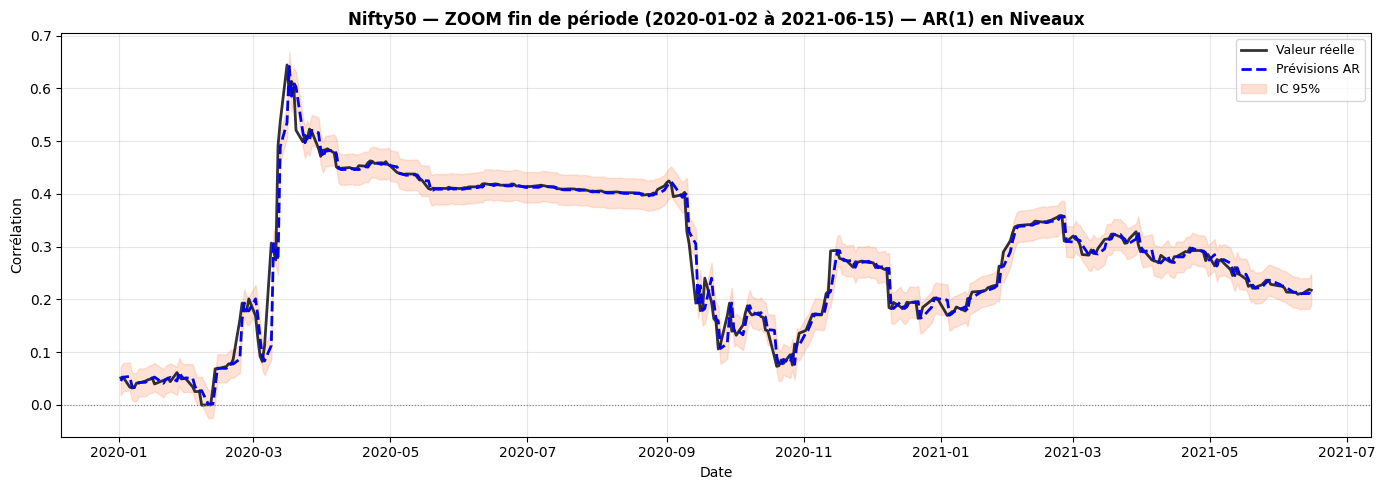

In [60]:
# Graphiques zoomés sur la fin de la période de test (2020-2021)

print(f"Période de test disponible : de {test_data.index[0].date()} à {test_data.index[-1].date()}\n")

for serie_name, result in results_dict.items():
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    
    # Récupérer les données
    test_series = test_data[f'corr_SP500_{serie_name}'].dropna()
    in_differences = result['in_differences']
    
    if in_differences:
        # Pour les modèles en différences : afficher les différences premières
        actuals_diff = test_series.diff().dropna().values
        forecasts = result['forecasts_diff']
        lower_ci = result['lower_ci_diff']
        upper_ci = result['upper_ci_diff']
        test_dates = test_series.index[1:len(actuals_diff)+1]
        ylabel = 'Différence de corrélation (Δρ)'
    else:
        # Pour les modèles en niveaux : afficher les niveaux
        forecasts = result['forecasts']
        lower_ci = result['lower_ci']
        upper_ci = result['upper_ci']
        actuals_diff = result['actuals']
        test_dates = test_series.index[:len(actuals_diff)]
        ylabel = 'Corrélation'
    
    # Filtrer sur la deuxième moitié de la période de test pour plus de détails
    mid_point = len(test_dates) // 2
    zoom_dates = test_dates[mid_point:]
    zoom_actuals = actuals_diff[mid_point:]
    zoom_forecasts = forecasts[mid_point:]
    zoom_lower_ci = lower_ci[mid_point:]
    zoom_upper_ci = upper_ci[mid_point:]
    
    # Tracer les valeurs réelles
    ax.plot(zoom_dates, zoom_actuals, label='Valeur réelle', 
            color='black', linewidth=2, alpha=0.8)
    
    # Tracer les prévisions
    ax.plot(zoom_dates, zoom_forecasts, label='Prévisions AR', 
            color='blue', linewidth=2, linestyle='--')
    
    # Intervalle de confiance à 95%
    ax.fill_between(zoom_dates, zoom_lower_ci, zoom_upper_ci, 
                     color='lightsalmon', alpha=0.3, label='IC 95%')
    
    # Annotations
    rmse = result['rmse']
    coverage = result['coverage']
    p = result['p']
    approach = "Différences" if in_differences else "Niveaux"
    
    ax.set_title(f"{serie_name} — ZOOM fin de période ({zoom_dates[0].date()} à {zoom_dates[-1].date()}) — AR({p}) en {approach}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()


##### Interprétation et évaluation de la fragilité des modèles AR

**Fragilité observée** :
Les modèles AR simples présentent plusieurs limites importantes :

1. **Précision limitée (RMSE)** : Les erreurs de prévision peuvent être substantielles, particulièrement pour les séries avec volatilité élevée ou changements structurels.

2. **Coverage des intervalles de confiance** : 
   - Un coverage proche de 95% indique une calibration correcte des IC
   - Un coverage significativement inférieur à 95% révèle une **sous-estimation du risque** (IC trop étroits)
   - Un coverage supérieur à 95% suggère une **surestimation du risque** (IC trop larges)

3. **Sensibilité aux événements extrêmes** : La période de test inclut la crise COVID-19 (mars 2020), un choc de marché majeur. Les modèles AR linéaires standards ont du mal à capturer ces ruptures.

4. **Hypothèse de linéarité** : Les modèles AR supposent une relation linéaire constante, inadéquate pour capturer les régimes de marché changeants (corrélations qui augmentent durant les crises).

**Recommandations** :
- Pour les séries avec coverage faible : considérer des modèles avec volatilité conditionnelle (GARCH)
- Pour les séries avec RMSE élevé : explorer des modèles non-linéaires (TAR, STAR) ou à changement de régime (Markov-switching)
- Utiliser des fenêtres d'estimation adaptatives (rolling window) pour mieux capturer les dynamiques récentes
- Intégrer des variables exogènes (VIX, spreads) pour améliorer la prévision durant les périodes de stress